In [1]:
import time
start_time=time.time()

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from spectral_cube import SpectralCube
from turbustat.simulator import make_ppv
from pathlib import Path
import astropy.units as u
from astropy.io import fits
from matplotlib import pyplot as plt
from skimage.util import random_noise

# Add path to py_modules 
sys.path.append(str(Path().resolve() / 'py_modules')) # 1 level up = project root
from turb_utils import make_extended, make_3dfield

In [3]:
# Fake map parameters
N             = 128
ra            = N / 16 # Artificial correlation length 
#sig_E         = 0 
sig_E         = 1 
#sig_E         = 2 
ellip         = 0.5
theta         = 45
amp           = 1.0
randomseed_vv = 1894_04_25
randomseed_sb = 1939_05_01
bin_size      = 0

# Fake obs parameters
s0    = 0
noise = 0
pc    = 1
pix   = 1
line  = 'NaN'

if sig_E == 0:
    m3D           = 0.0   # for recovering m as 1.00 in the projected field (k = 3D + m3D) non-fluctuations sigE = 0
elif sig_E == 1:
    m3D           = 0.30  # for recovering m as 1.00 in the projected field (k = 3D + m3D) light fluctuations sigE = 1
elif sig_E == 2:
    m3D           = 0.55  # for recovering m as 1.00 in the projected field (k = 3D + m3D) light fluctuations sigE = 1

print(m3D)

0.3


In [4]:
name  = 'fake_cube_mod_finite'+'_sigE' + str(int(sig_E)) +'_m' +str(int((3+m3D)*100))+'_r' +str(int(ra))+ '_N' +str(N)
name

'fake_cube_mod_finite_sigE1_m330_r8_N128'

In [5]:
## Emissivity fluctuations test I

density = make_3dfield(N, 
    powerlaw            = 3.0 + m3D, 
    correlation_length  = ra,  
    amp                 = amp,
    ellip               = ellip,
    theta               = theta,
    randomseed          = randomseed_sb) * u.cm**-3 

density = (density-density.mean())/density.std()

emissivity = np.exp(sig_E * density) * u.cm**-3 # Check this!!


In [6]:
# Velocity fluctuations

velocity = make_3dfield(N,
    powerlaw            = 3.0 + m3D,
    correlation_length  = ra,  
    amp                 = amp,
    ellip               = ellip,
    theta               = theta,
    randomseed          = randomseed_vv)* u.km / u.s   


In [7]:
# Making PPV cube

cube_hdu = make_ppv(velocity, emissivity, los_axis=0,
                    T=10000 * u.K, chan_width=0.5 * u.km / u.s,
                    v_min=-20 * u.km / u.s,
                    v_max=20 * u.km / u.s)  

cube = SpectralCube.read(cube_hdu)  

In [8]:
sb = cube.moment0().value
vv = cube.moment1().value

sig = vv.std()
vv /= sig

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ZAINTEL2\AppData\Local\Temp\ipykernel_10016\126694012.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


Text(0.5, 0, 'pix')

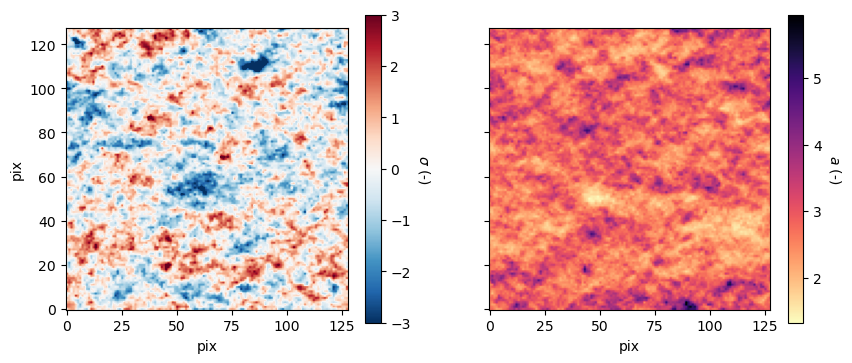

In [9]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", vmin=-3, vmax=3, cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma_r")
im = ax.imshow(vv, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)

ax.set_xlabel("pix")
ax.set_ylabel("pix")
axx.set_xlabel("pix")

#ax.set_title("3D Tapered")
#axx.set_title("3D Non Tapered")


In [10]:
hdr = fits.Header()
hdr["AUTHOR"]   = ("J. Garcia-Vazquez", "File creator")
hdr["m3D"]      = (m3D, "k = 3 + m3D")
hdr["ra"]       = (ra, "Artificial correlation length")
hdr["sig"]      = (sig, "Standard deviation vel artificial map")
hdr["sig2"]     = (sig**2, "Vel Variance artificial map")
hdr["s0"]       = (s0, "Atmospheric seeing")
hdr["noise"]    = (noise, "Instrumental noise")
hdr["box_size"] = (N, "Observational box_size")
hdr["pc"]       = (pc, "parsec convertion")
hdr["pix"]      = (pix, "Instrument pixel scale")
hdr["LINE"]     = ("H_I-6563", "Emission line name")
hdr["BINSIZE"]  = (0, "Spatial binning factor")
hdr["SEED1"]     = (randomseed_vv, "Random seed velocity")
hdr["SEED2"]     = (randomseed_sb, "Random seed surfavebrightness")

In [11]:
primary_hdu = fits.PrimaryHDU(header=hdr)
hdu_m0 = fits.ImageHDU(data=sb,  name='MOM0')
hdu_m1 = fits.ImageHDU(data=vv,  name='MOM1')

In [12]:
hdul = fits.HDUList([primary_hdu, hdu_m0, hdu_m1])

In [13]:
hdul.writeto(name + '.fits', overwrite=True)

In [14]:
print("--- %s seconds ---" % (time.time()-start_time))

--- 39.57885670661926 seconds ---
